In [1]:
from typing import Optional
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error

def evaluate_volume_model(df: pd.DataFrame,
                          halflife: float,
                          lookahead: float,
                          side: Optional[str] = None) -> float:
    """
    返回 MAE（越小越好）。lookahead 可以是 0.1–5.0 秒的浮点数。
    """
    if df.empty:
        return np.inf                     # 无数据 → 无穷大

    # ---------- 方向过滤 ----------
    if side == "buy":
        df = df[df["v"] > 0]
    elif side == "sell":
        df = df[df["v"] < 0]
    if df.empty:
        return np.inf

    # ---------- 秒级时间序列 ----------
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["ts"], unit="ms", utc=True)
    trades = df.set_index("datetime").sort_index()
    trades["vol"] = trades["v"].abs()
    vol_1s = trades["vol"].resample("1s").sum().fillna(0)

    # ---------- 预测 ----------
    pred = vol_1s.ewm(halflife=halflife, adjust=False).mean()

    # ---------- 标签：未来 lookahead 秒（不含当前秒） ----------
    true = (vol_1s.shift(-1)                                   # 从 t+1 开始
            .rolling(f'{lookahead}s', min_periods=1)           # 时间窗
            .sum())

    aligned = pd.DataFrame({"pred": pred, "true": true}).dropna()
    if aligned.empty:
        return np.inf

    return mean_absolute_error(aligned["true"], aligned["pred"])


In [2]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2024-01-15", "2024-01-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("binance", "swap", "btc-usdt", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))


loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_15.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_16.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_17.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_18.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_19.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_20.hdf 
loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2024_01_21.hdf 
Merged rows: 6524246


In [ ]:
import numpy as np
from itertools import product

HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)       

results = []
for hl, la in product(HALFLIFES, LOOKAHEADS):
    mae_buy  = evaluate_volume_model(week_df, hl, la, side="buy")
    mae_sell = evaluate_volume_model(week_df, hl, la, side="sell")
    mae_avg  = np.mean([mae_buy, mae_sell])  # 也可以分别画

    results.append({"halflife": hl,
                    "lookahead": la,
                    "MAE": mae_avg})

grid_df = pd.DataFrame(results)


In [7]:
grid_df

,halflife,lookahead,MAE
0,0.1,1,1.885155
1,0.1,2,1.306869
2,0.1,3,2.613406
3,0.1,4,3.920109
4,0.1,5,5.226811
...,...,...,...
495,65.0,1,1.641210
496,65.0,2,2.345808
497,65.0,3,3.284215
498,65.0,4,4.361435


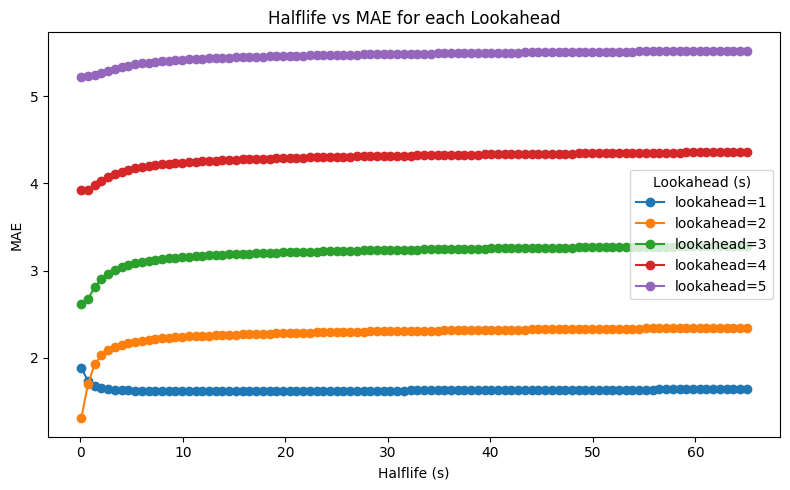

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")

df = grid_df.copy()

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()


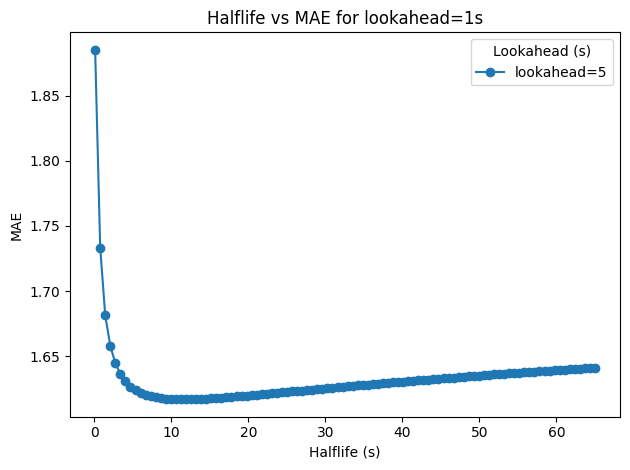

In [10]:
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()



## 带零样本以及+exchange＝coinexv2+type＝swap+btc/eth/sol/doge/xrp

# BTC

In [22]:
from typing import Optional
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error

def evaluate_volume_model(df: pd.DataFrame,
                          halflife: float,
                          lookahead: float,
                          side: Optional[str] = None):
    df = (df.apply(pd.to_numeric, errors="coerce")   # → 无法解析的值变 NaN
        .dropna()                               # → 任何列出现 NaN 的整行删除
        .astype(int))                           # → 全部安全地转成 int

    
    if df.empty:
        return np.inf                     # 无数据 → 无穷大

    # ---------- 方向过滤 ----------
    if side == "buy":
        df = df[df["v"] > 0]
    elif side == "sell":
        df = df[df["v"] < 0]
    if df.empty:
        return np.inf

    # ---------- 秒级时间序列 ----------
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["ts"], unit="ms", utc=True)
    trades = df.set_index("datetime").sort_index()
    trades["vol"] = trades["v"].abs()
    vol_1s = trades["vol"].resample("1s").sum().fillna(0)

    # ---------- 预测 ----------
    pred = vol_1s.ewm(halflife=halflife, adjust=False).mean()
    true = (vol_1s.shift(-1)                                   
            .rolling(f'{lookahead}s', min_periods=1)           
            .sum())
    aligned = pd.DataFrame({"pred": pred, "true": true}).dropna()
    if aligned.empty:
        return {"MAE": np.inf, "zero_ratio": 1.0}

    mae  = mean_absolute_error(aligned["true"], aligned["pred"])
    zrat = (aligned["true"] == 0).mean()          # 0~1 之间

    return {"MAE": mae, "zero_ratio": zrat}


In [3]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2025-03-15", "2025-03-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("COINEXV2", "SWAP", "BTC-USD", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_15.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_16.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_17.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_18.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_19.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_20.hdf 
loading... AWS-JP1_COINEXV2_SWAP_BTC-USD_TRADE_2025_03_21.hdf 
Merged rows: 50162


In [4]:
from itertools import product
results = []
HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)  
for hl, la in product(HALFLIFES, LOOKAHEADS):
    for side in ('buy', 'sell'):
        out = evaluate_volume_model(week_df, hl, la, side=side)
        results.append({"halflife": hl,
                        "lookahead": la,
                        "side": side,
                        **out})          # 解包 MAE / zero_ratio
grid_df = pd.DataFrame(results)
grid_df

,halflife,lookahead,side,MAE,zero_ratio
0,0.1,1,buy,71.746186,0.964830
1,0.1,1,sell,73.046967,0.964954
2,0.1,2,buy,42.861370,0.934437
3,0.1,2,sell,44.522334,0.934898
4,0.1,3,buy,85.622229,0.908900
...,...,...,...,...,...
995,65.0,3,sell,162.473539,0.909620
996,65.0,4,buy,196.287867,0.885736
997,65.0,4,sell,203.918135,0.886747
998,65.0,5,buy,236.500236,0.864065


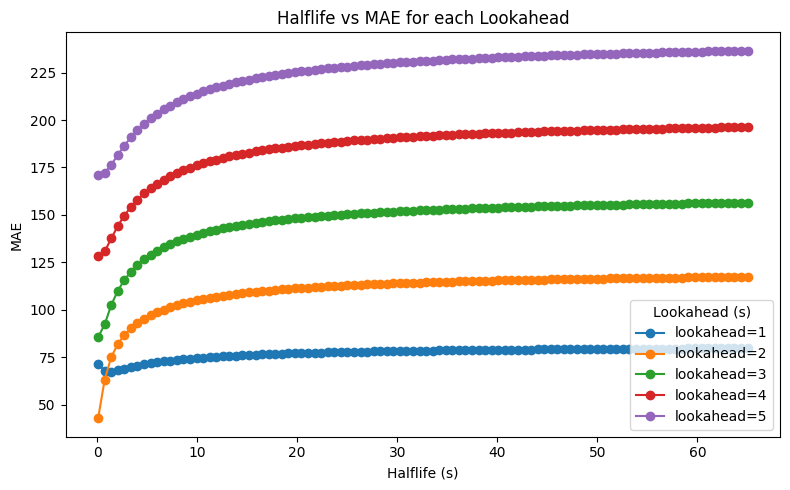

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()
df= df[df['side'] == 'buy']  # 只看买方

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()


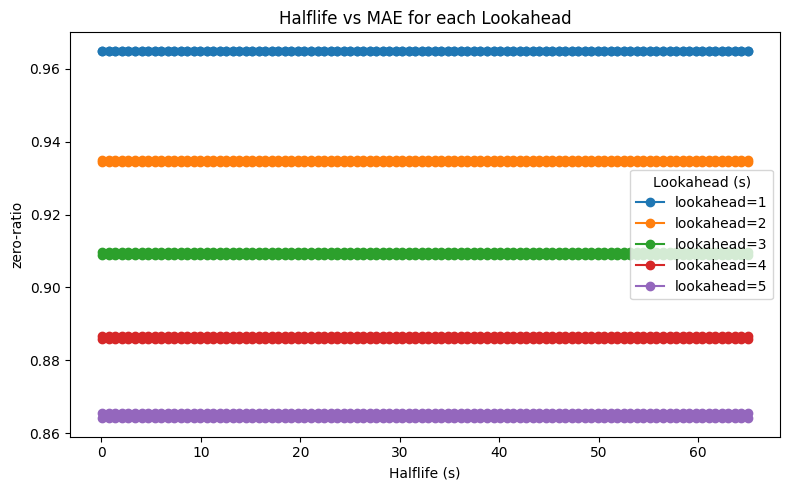

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['zero_ratio'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('zero-ratio')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()


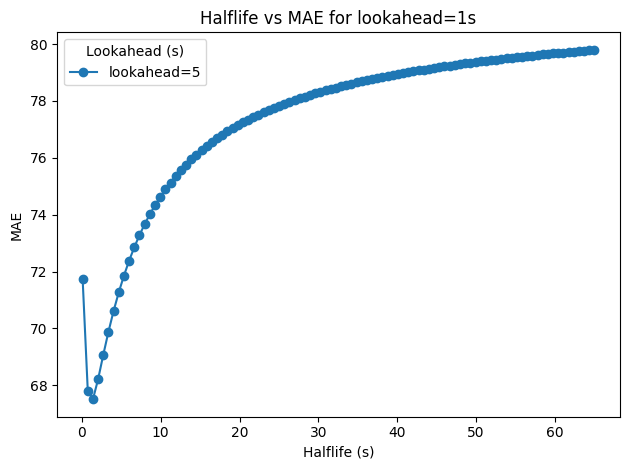

In [ ]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()


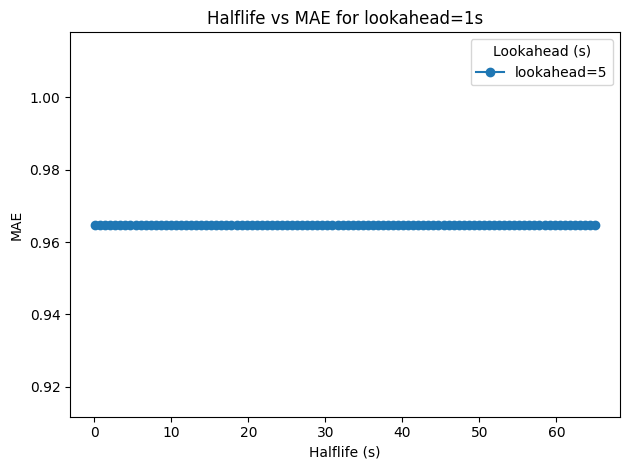

In [8]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['zero_ratio'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

# ETH

In [9]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2025-03-15", "2025-03-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("COINEXV2", "SWAP", "ETH-USD", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_15.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_15.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_16.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_16.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_17.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_17.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_18.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_18.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_19.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_19.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_20.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_20.hdf 
downloading AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_21.hdf
loading... AWS-JP1_COINEXV2_SWAP_ETH-USD_TRADE_2025_03_21.hdf 
Merged rows: 30374


In [10]:
from itertools import product
results = []
HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)  
for hl, la in product(HALFLIFES, LOOKAHEADS):
    for side in ('buy', 'sell'):
        out = evaluate_volume_model(week_df, hl, la, side=side)
        results.append({"halflife": hl,
                        "lookahead": la,
                        "side": side,
                        **out})          # 解包 MAE / zero_ratio
grid_df = pd.DataFrame(results)
grid_df

,halflife,lookahead,side,MAE,zero_ratio
0,0.1,1,buy,8.648415,0.982528
1,0.1,1,sell,11.649515,0.975231
2,0.1,2,buy,5.173065,0.966547
3,0.1,2,sell,7.328717,0.953537
4,0.1,3,buy,10.333559,0.952119
...,...,...,...,...,...
995,65.0,3,sell,26.825635,0.934911
996,65.0,4,buy,24.015481,0.938556
997,65.0,4,sell,33.675216,0.917834
998,65.0,5,buy,28.905578,0.925562


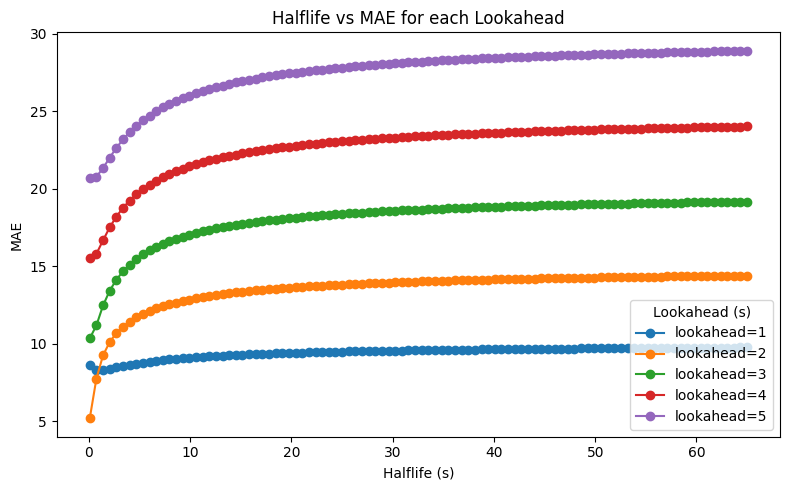

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()
df= df[df['side'] == 'buy']  # 只看买方

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

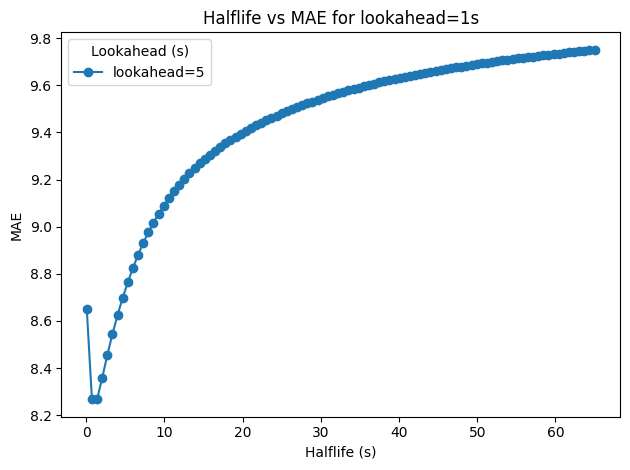

In [12]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

# SOL

In [14]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2025-03-15", "2025-03-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("COINEXV2", "SWAP", "SOL-USDT", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_15.hdf


loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_15.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_16.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_16.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_17.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_17.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_18.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_18.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_19.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_19.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_20.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_20.hdf 
downloading AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_21.hdf
loading... AWS-JP1_COINEXV2_SWAP_SOL-USDT_TRADE_2025_03_21.hdf 
Merged rows: 267681


In [23]:
from itertools import product
results = []
HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)  
for hl, la in product(HALFLIFES, LOOKAHEADS):
    for side in ('buy', 'sell'):
        out = evaluate_volume_model(week_df, hl, la, side=side)
        results.append({"halflife": hl,
                        "lookahead": la,
                        "side": side,
                        **out})          # 解包 MAE / zero_ratio
grid_df = pd.DataFrame(results)
grid_df

,halflife,lookahead,side,MAE,zero_ratio
0,0.1,1,buy,3.771207,0.862018
1,0.1,1,sell,3.903935,0.855726
2,0.1,2,buy,2.323155,0.758784
3,0.1,2,sell,2.429424,0.749602
4,0.1,3,buy,4.641534,0.686880
...,...,...,...,...,...
995,65.0,3,sell,7.729725,0.677623
996,65.0,4,buy,9.400004,0.631608
997,65.0,4,sell,9.815116,0.622842
998,65.0,5,buy,11.459746,0.586479


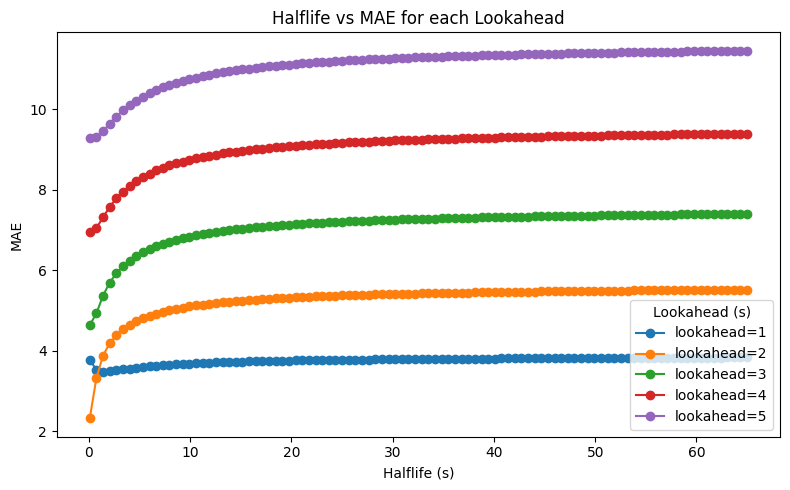

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()
df= df[df['side'] == 'buy']  # 只看买方

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

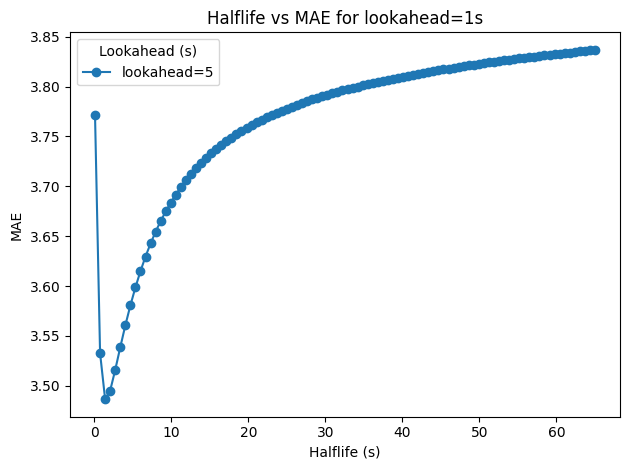

In [25]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

# DOGE

In [26]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2025-03-15", "2025-03-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("COINEXV2", "SWAP", "DOGE-USDT", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_15.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_15.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_16.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_16.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_17.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_17.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_18.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_18.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_19.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_19.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_20.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_20.hdf 
downloading AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_21.hdf
loading... AWS-JP1_COINEXV2_SWAP_DOGE-USDT_TRADE_2025_03_21.hdf 
Merged rows: 188986


In [27]:
from itertools import product
results = []
HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)  
for hl, la in product(HALFLIFES, LOOKAHEADS):
    for side in ('buy', 'sell'):
        out = evaluate_volume_model(week_df, hl, la, side=side)
        results.append({"halflife": hl,
                        "lookahead": la,
                        "side": side,
                        **out})          # 解包 MAE / zero_ratio
grid_df = pd.DataFrame(results)
grid_df

,halflife,lookahead,side,MAE,zero_ratio
0,0.1,1,buy,1665.172596,0.884297
1,0.1,1,sell,1709.847879,0.883789
2,0.1,2,buy,1009.965850,0.796603
3,0.1,2,sell,1039.959721,0.796123
4,0.1,3,buy,2017.732869,0.733460
...,...,...,...,...,...
995,65.0,3,sell,3492.679958,0.733646
996,65.0,4,buy,4291.815127,0.682572
997,65.0,4,sell,4408.919867,0.683715
998,65.0,5,buy,5203.031045,0.639574


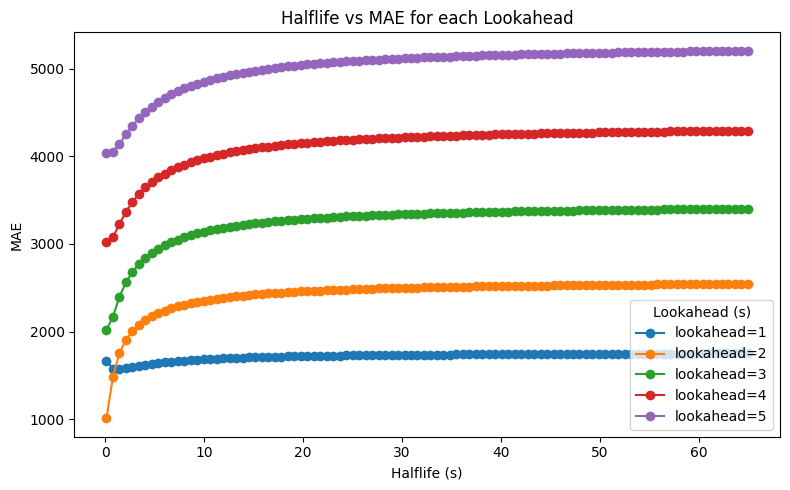

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()
df= df[df['side'] == 'buy']  # 只看买方

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

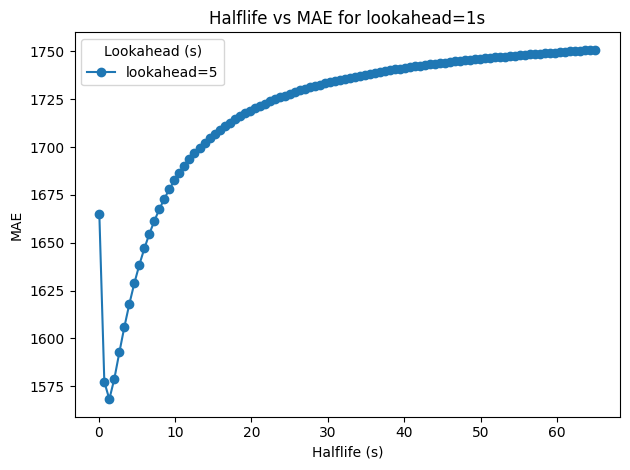

In [29]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

# XRP

In [30]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta

dates = pd.date_range("2025-03-15", "2025-03-21", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("COINEXV2", "SWAP", "XRP-USDT", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_15.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_15.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_16.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_16.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_17.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_17.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_18.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_18.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_19.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_19.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_20.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_20.hdf 
downloading AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_21.hdf
loading... AWS-JP1_COINEXV2_SWAP_XRP-USDT_TRADE_2025_03_21.hdf 
Merged rows: 256014


In [31]:
from itertools import product
results = []
HALFLIFES  = np.linspace(0.1, 65, 100)      # 0.1‒65  共 100 点
LOOKAHEADS = np.arange(1,6)  
for hl, la in product(HALFLIFES, LOOKAHEADS):
    for side in ('buy', 'sell'):
        out = evaluate_volume_model(week_df, hl, la, side=side)
        results.append({"halflife": hl,
                        "lookahead": la,
                        "side": side,
                        **out})          # 解包 MAE / zero_ratio
grid_df = pd.DataFrame(results)
grid_df

,halflife,lookahead,side,MAE,zero_ratio
0,0.1,1,buy,247.216921,0.858964
1,0.1,1,sell,257.011024,0.850449
2,0.1,2,buy,153.439044,0.755574
3,0.1,2,sell,160.935716,0.742532
4,0.1,3,buy,306.583818,0.682977
...,...,...,...,...,...
995,65.0,3,sell,509.027642,0.669016
996,65.0,4,buy,617.926525,0.626205
997,65.0,4,sell,647.431291,0.612257
998,65.0,5,buy,754.463368,0.579461


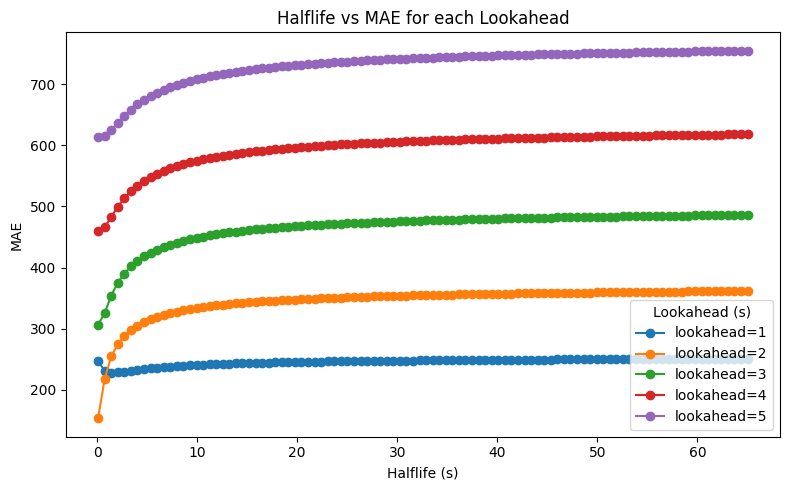

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Safety check
if 'grid_df' not in globals():
    raise NameError("grid_df (包含 halflife / lookahead / MAE) 未在当前内存，"
                    "请先运行网格搜索生成表格后再执行此绘图 cell。")
grid_df_coinbtc=grid_df
df = grid_df.copy()
df= df[df['side'] == 'buy']  # 只看买方

# Sort values for cleaner lines
df.sort_values(['lookahead', 'halflife'], inplace=True)

plt.figure(figsize=(8,5))
for la in sorted(df['lookahead'].unique()):
    sub = df[df['lookahead'] == la]
    plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for each Lookahead')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()

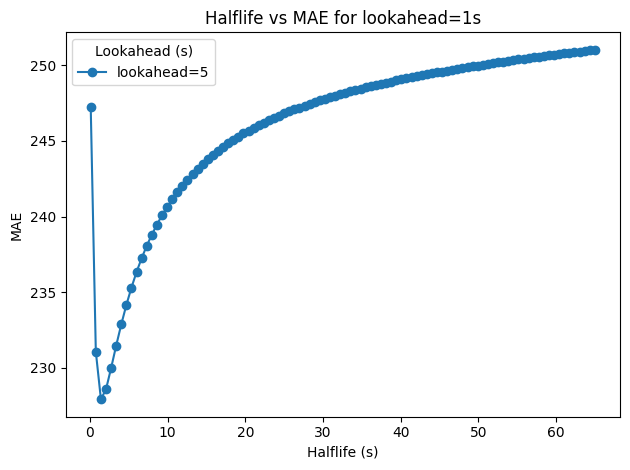

In [33]:
df= df[df['side'] == 'buy'] 
sub = df[df['lookahead'] == 1]
plt.plot(sub['halflife'], sub['MAE'], marker='o', label=f'lookahead={la}')

plt.xlabel('Halflife (s)')
plt.ylabel('MAE')
plt.title('Halflife vs MAE for lookahead=1s')
plt.legend(title='Lookahead (s)')
plt.tight_layout()
plt.show()
